SAE 2.04
TD4
Equipe 5 : DURAN Kalvin, EAR Francois, EL KANIZI Loubna, ORDAS Ethan, RAOUX Matheo

In [2]:
import os

print("Dossier de travail actuel :")
print(os.getcwd())

print("\nFichiers et dossiers détectés ici :")
print(os.listdir())

Dossier de travail actuel :
/amuhome/e25017332/Exploitation_BD_SAE/SAE2.04-BDD

Fichiers et dossiers détectés ici :
['faker_output_v2', '.ipynb_checkpoints', 'faker_script.py', 'faker_output_v2.zip', 'faker_output_sql.zip', '.git', 'Intention.txt', 'TD4 _Equipe 5 _SAE204.ipynb']


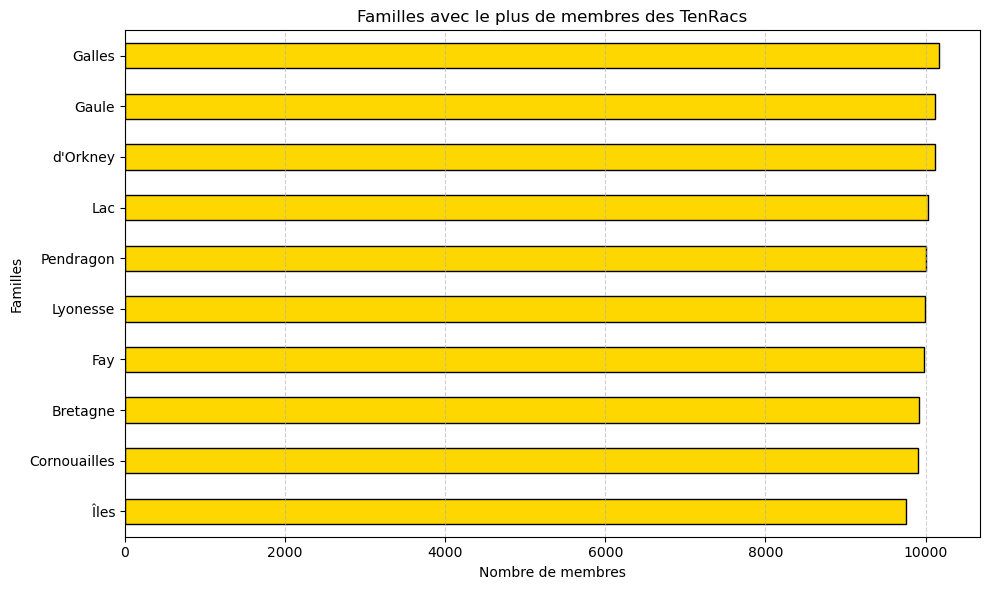

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('faker_output_v3/Membre.csv')

# groupage par famille et on prend les 10 premiers
top_familles = df.groupby(df['nom_membre'].str.split().str[-1]).size().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_familles.plot(kind='barh', color='gold', edgecolor='black')

plt.title('Familles avec le plus de membres des TenRacs')
plt.xlabel('Nombre de membres')
plt.ylabel('Familles')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Ce sont les familles qui possède le plus de membres, ici on peut observer que les familles "Galles", "Gaule" et "D'Orkney" possède plus de 10.000 membres. 

In [17]:
import pandas as pd

df = pd.read_csv('faker_output_v3/Membre.csv')

df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs_par_famille = df['famille'].value_counts()

# moyenne des membres par famille
moyenne_membres_famille = effectifs_par_famille.mean()

print(f"En moyenne, chaque famille compte {moyenne_membres_famille:.2f} membres.")

# maximum et minimum 
print(f"Famille avec le plus de membres: {effectifs_par_famille.max()} membres")
print(f"Famille le moins de membres : {effectifs_par_famille.min()} membre(s)")

print("\nFamilles dominantes :")
print(effectifs_par_famille.head(5))

En moyenne, chaque famille compte 10000.00 membres.
Famille avec le plus de membres: 10171 membres
Famille le moins de membres : 9756 membre(s)

Familles dominantes :
famille
Galles       10171
Gaule        10121
d'Orkney     10118
Lac          10036
Pendragon    10010
Name: count, dtype: int64


In [19]:
import pandas as pd

df = pd.read_csv('faker_output_v3/Membre.csv')

# extraction de la ville (dernier mot de l'adresse)
df['famille'] = df['nom_membre'].str.split().str[-1]
effectifs_par_famille = df.groupby('famille').size()

# calcul de l'écart-type
ecart_type_famille = effectifs_par_famille.std()

print(f"Écart-type : {ecart_type_famille:.2f}")
print(f"En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.")

Écart-type : 122.79
En calculant le coefficient de variation on trouve 1,22%, on considère donc la répartition homogène.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('faker_output_v3/Membre.csv')
df['famille'] = df['nom_membre'].str.split().str[-1]

effectifs = df.groupby('famille').size()

#  25%, 50% (médiane) et 75%
quartiles = effectifs.quantile([0.25, 0.5, 0.75])

print(f" 25% : {quartiles[0.25]}")
print(f"Médiane (50%) : {quartiles[0.50]}")
print(f" 75% : {quartiles[0.75]}")

 25% : 9930.25
Médiane (50%) : 10000.0
 75% : 10097.5


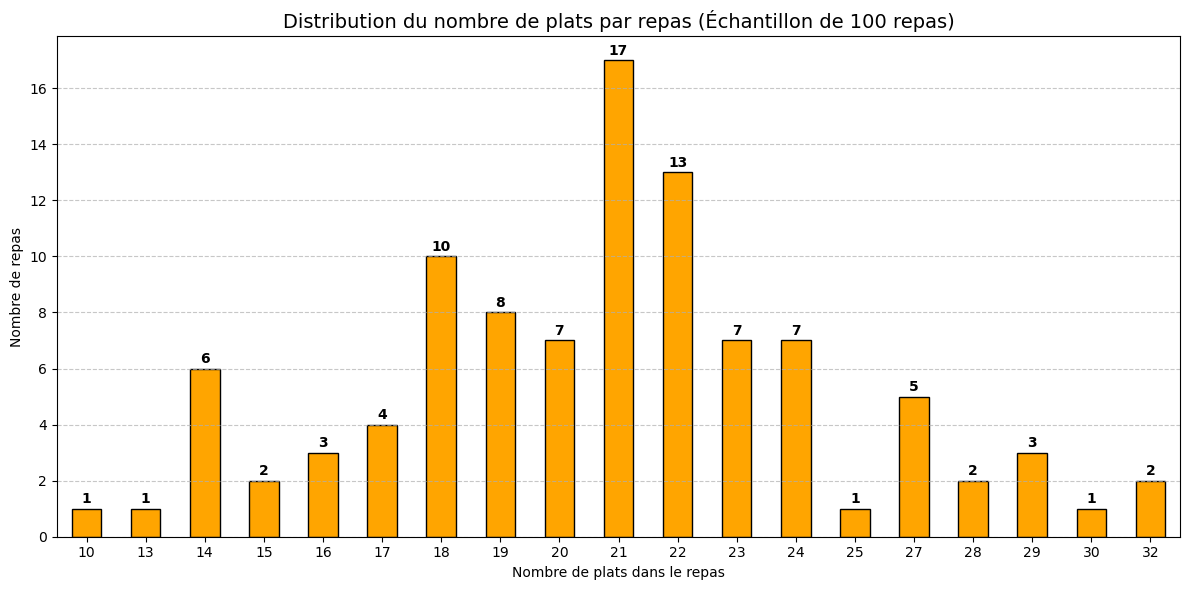

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


contient = pd.read_csv('faker_output_v3/contient.csv')

# echantillon de 100 repas uniques
repas_ids = contient['IdR'].unique()[:100]
df_100 = contient[contient['IdR'].isin(repas_ids)]

# compte le nombre de plats
plats_par_repas = df_100.groupby('IdR')['IdP'].count()

# on regarde combien de repas ont 10 plats, 15 plats, etc
distribution = plats_par_repas.value_counts().sort_index()

# creation du graphique en barres
plt.figure(figsize=(12, 6))
distribution.plot(kind='bar', color='orange', edgecolor='black')

# on ajoute les valeurs au dessus des barres 
for i, v in enumerate(distribution):
    plt.text(i, v + 0.2, str(int(v)), ha='center', fontweight='bold')

plt.title('Distribution du nombre de plats par repas (Échantillon de 100 repas)', fontsize=14)
plt.xlabel('Nombre de plats dans le repas')
plt.ylabel('Nombre de repas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# pas de debordement
plt.tight_layout()
plt.show()

Ce sont le nombre de plats distribuer PAR repas.

In [2]:
import pandas as pd

df = pd.read_csv('faker_output_v3/contient.csv')

# compte le nombre de plats par repas (idR)
nb_plats_par_repas = df.groupby('IdR')['IdP'].count()

# calcule de la médiane
mediane = nb_plats_par_repas.median()

print(f"La médiane est de {mediane} plats par repas")

La médiane est de 20.0 plats par repas.


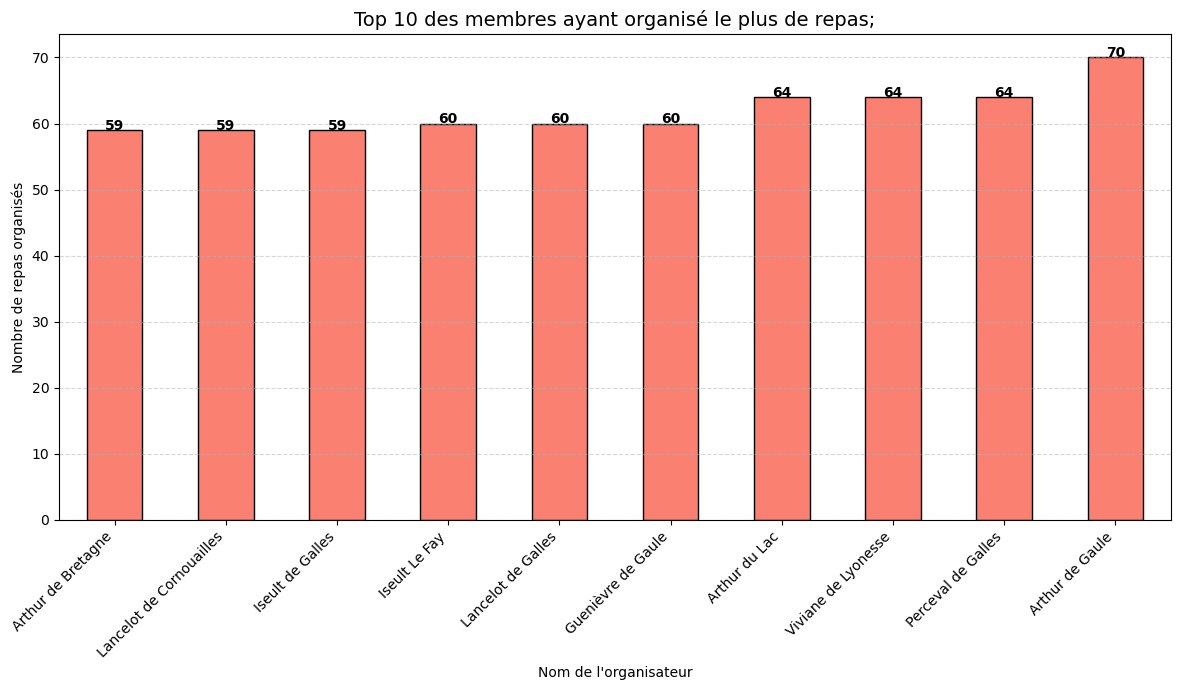

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


repas = pd.read_csv('faker_output_v3/Repas.csv')

# trie par ordre croissant
top_10 = repas['nom_chevalier_dame'].value_counts().head(10).sort_values(ascending=True)

# creation des barres verticale
top_10.plot(kind='bar', color='salmon', edgecolor='black', figsize=(12, 7))

# chiffrage au dessus des barres
for i, v in enumerate(top_10):
    plt.text(i, v + 0.05, str(int(v)), ha='center', fontweight='bold')

plt.title('Top 10 des membres ayant organisé le plus de repas;', fontsize=14)
plt.xlabel('Nom de l\'organisateur')
plt.ylabel('Nombre de repas organisés')

# (inclinaison pour que les noms ne se chevauchent pas)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# evite le debordement
plt.tight_layout()
plt.show()

C'est le top 10 des membres des TenRacs qui a organisé le plus de repas. 